Vector Stores and Retrievers

In [1]:
# We will go through vector store and retriever abstractions. These abstractions are designed to support retrieval of data from (vector) databases and other sources -- for integration with LLM workflows. They are important for applications that fetch data to be reasoned over as part of model inference, as in the case of retrieval augmented generation

In [2]:
# Documents
# Langchain implements a Document abstraction which is intended to represent a unit of text and associated metadata. It has two attributes :
# 1) Page content :  a string representing the content
# 2) Metadata : A dict containing arbitrary metadata. The metadata attribute can capture info about the source of the doc, its relationship to other documents,and other info. Note that an individual Doc object often represents a chunk of a larger doc.

In [3]:
# Generating sample docs:
from langchain_core.documents import Document
documents = [Document(
    page_content="Dogs are great companions known for their loyalty and friendliness",
    metadata = {"source":"mammal-pets.doc"},

),
       Document(page_content="Cats are independent pets that often enjoy their own space",
                metadata ={"source":"fish=pets-doc"})]

In [4]:
documents

[Document(metadata={'source': 'mammal-pets.doc'}, page_content='Dogs are great companions known for their loyalty and friendliness'),
 Document(metadata={'source': 'fish=pets-doc'}, page_content='Cats are independent pets that often enjoy their own space')]

In [7]:
import os
from dotenv import load_dotenv
load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")

os.environ["HUGGING_FACE_API_KEY"]=os.getenv("HUGGING_FACE_API_KEY")

In [8]:
from langchain_groq import ChatGroq
llm = ChatGroq(groq_api_key=groq_api_key,model="groq/compound")

In [10]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

In [12]:
# vectorstores
from langchain_chroma import Chroma
vectorstore = Chroma.from_documents(documents,embedding=embeddings)
vectorstore


In [13]:
vectorstore.similarity_search("cat")

[Document(id='49b76745-540e-4003-8bbe-ce963db1e2cf', metadata={'source': 'fish=pets-doc'}, page_content='Cats are independent pets that often enjoy their own space'),
 Document(id='826ac19f-74f2-4e6b-8b2f-deda003cbb63', metadata={'source': 'fish=pets-doc'}, page_content='Cats are independent pets that often enjoy their own space'),
 Document(id='5d54490f-4c0b-4232-8880-bf515d627530', metadata={'source': 'mammal-pets.doc'}, page_content='Dogs are great companions known for their loyalty and friendliness'),
 Document(id='2d1b27cc-4877-4ea4-ad7e-1d323ca057da', metadata={'source': 'mammal-pets.doc'}, page_content='Dogs are great companions known for their loyalty and friendliness')]

In [15]:
# async query is also supported
await vectorstore.asimilarity_search("cat")

[Document(id='49b76745-540e-4003-8bbe-ce963db1e2cf', metadata={'source': 'fish=pets-doc'}, page_content='Cats are independent pets that often enjoy their own space'),
 Document(id='826ac19f-74f2-4e6b-8b2f-deda003cbb63', metadata={'source': 'fish=pets-doc'}, page_content='Cats are independent pets that often enjoy their own space'),
 Document(id='5d54490f-4c0b-4232-8880-bf515d627530', metadata={'source': 'mammal-pets.doc'}, page_content='Dogs are great companions known for their loyalty and friendliness'),
 Document(id='2d1b27cc-4877-4ea4-ad7e-1d323ca057da', metadata={'source': 'mammal-pets.doc'}, page_content='Dogs are great companions known for their loyalty and friendliness')]

Retrievers

![WhatsApp Image 2025-12-02 at 12.44.39 PM.jpeg](<attachment:WhatsApp Image 2025-12-02 at 12.44.39 PM.jpeg>)
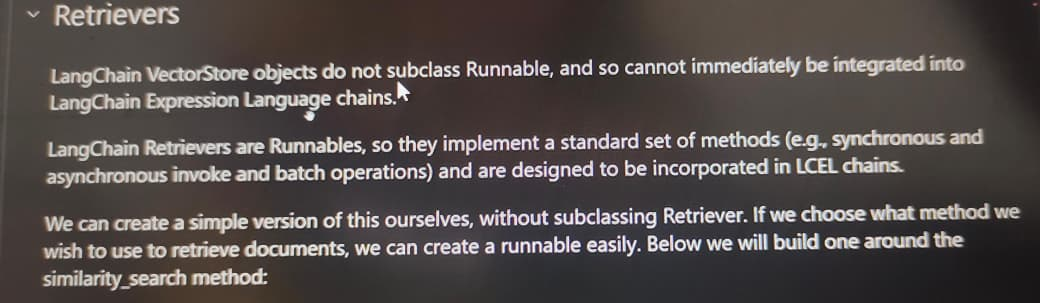

In [16]:
from typing import List
from langchain_core.documents import Document
from langchain_core.runnables import RunnableLambda

retriever = RunnableLambda(vectorstore.similarity_search).bind(k=1)
retriever.batch(["dog","cat"])  
# this runnable lambda will first do a similarity search for dog and return k most similar documents, then do the same for cat.
# whatever we give inside batch will be passed to the similarity_search method of the vectorstore when we use runnable lambda.


[[Document(id='2d1b27cc-4877-4ea4-ad7e-1d323ca057da', metadata={'source': 'mammal-pets.doc'}, page_content='Dogs are great companions known for their loyalty and friendliness')],
 [Document(id='826ac19f-74f2-4e6b-8b2f-deda003cbb63', metadata={'source': 'fish=pets-doc'}, page_content='Cats are independent pets that often enjoy their own space')]]

Vectore Stores implement an as_retriever method that will generate a retriever specifically a VectorStoreRetrieverr. These retrievers include specific search_type and search_kwargs attributes that identify what methods of the underlying vector store to call, and how to parameterize them. For instance, we can replicate the above with the following :

In [17]:
retriever=vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k":1} # give top k results 
)
# this retriever acts as an interface to take any info from the vectorstore and give it as a response.
retriever.batch(["dog","cat"])

[[Document(id='2d1b27cc-4877-4ea4-ad7e-1d323ca057da', metadata={'source': 'mammal-pets.doc'}, page_content='Dogs are great companions known for their loyalty and friendliness')],
 [Document(id='826ac19f-74f2-4e6b-8b2f-deda003cbb63', metadata={'source': 'fish=pets-doc'}, page_content='Cats are independent pets that often enjoy their own space')]]

In [23]:
# rag
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough

message = """
Answer this question using the provided context only.
{question}

Context:
{context}
"""
prompt = ChatPromptTemplate.from_messages([("human",message)])
# here the context is the retriever which is the vectorstore retriever we created above.
# the question is just passed as it is using runnable passthrough which we define.
# prompt will format the input by putting the context and question in the right places.

rag_chain={"context": retriever,"question": RunnablePassthrough() } | prompt | llm

In [21]:
response = rag_chain.invoke("tell me about dogs")

In [22]:
response.content

'Dogs are great companions known for their loyalty and friendliness.'